In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point

In [2]:
# load precipitation data

prec = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week5\precip.mon.mean.nc")
prec = prec.sel(time = slice('1979', '2019')) 
prec.load()

<xarray.Dataset>
Dimensions:    (lat: 72, lon: 144, time: 492, nv: 2)
Coordinates:
  * lat        (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon        (lon) float32 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 1979-01-01 1979-02-01 ... 2020-01-01
    lat_bnds   (lat, nv) float32 -90.0 -87.5 -87.5 -85.0 ... 85.0 87.5 87.5 90.0
    lon_bnds   (lon, nv) float32 0.0 2.5 2.5 5.0 5.0 ... 355.0 357.5 357.5 360.0
    precip     (time, lat, lon) float32 0.0 0.0 0.0 0.0 ... 0.1305 0.1327 0.1341
Attributes: (12/18)
    Conventions:           CF-1.0
    curator:               Dr. Jian-Jian Wang\nESSIC, University of Maryland ...
    citation:              Adler, R.F., G.J. Huffman, A. Chang, R. Ferraro, P...
    title:                 GPCP Version 2.3 Combined Precipitation Dataset (F...
    platform:              NOAA POES (Polar Orbiting Environmental Satellites)
    source_obs:            CDR RSS SSMI/SSMIS Tbs over ocean \nCDR SSMI/SSMIS...
    ...                    ...
    source:                https://www.ncei.noaa.gov/data/global-precipitatio...
    source_documentation:  https://www.ncdc.noaa.gov/cdr/atmospheric/precipit...
    NCO:                   4.6.9
    history:               Generated at NOAA/ESRL PSD Sep 9 2016 based on dat...
    References:            http://www.psl.noaa.gov/data/gridded/data.gpcp.html
    data_comment:          Interim data covers 2023/01 through latest.

In [3]:
# load temperature data

temp = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week6\air.mon.mean.nc")
temp = temp.sel(time = slice('1979', '2019')) 
temp.load()

<xarray.Dataset>
Dimensions:  (lat: 73, lon: 144, time: 492)
Coordinates:
  * lat      (lat) float32 90.0 87.5 85.0 82.5 80.0 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
Data variables:
    air      (time, lat, lon) float32 -34.91 -34.91 -34.91 ... -22.48 -22.48
Attributes:
    description:    Data from NCEP initialized reanalysis (4x/day).  These ar...
    platform:       Model
    Conventions:    COARDS
    NCO:            20121012
    history:        Thu May  4 20:11:16 2000: ncrcat -d time,0,623 /Datasets/...
    title:          monthly mean air.sig995 from the NCEP Reanalysis
    dataset_title:  NCEP-NCAR Reanalysis 1
    References:     http://www.psl.noaa.gov/data/gridded/data.ncep.reanalysis...

In [4]:
# load SST data

sst = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week6\sst.mnmean.nc")
#ds_sst = ds_sst.sel(time = slice('1979', '2019')) 
sst.load()

<xarray.Dataset>
Dimensions:    (lat: 89, lon: 180, time: 2030, nbnds: 2)
Coordinates:
  * lat        (lat) float32 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon        (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1854-01-01 1854-02-01 ... 2023-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
    sst        (time, lat, lon) float32 -1.8 -1.8 -1.8 -1.8 ... nan nan nan nan
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    creator_url_original:      https://www.ncei.noaa.gov
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2023-03-04

In [5]:
#make anomaly
sst_clim = sst.sst.groupby('time.month').mean(dim = 'time')
sst_anom = sst.sst.groupby('time.month') - sst_clim

In [6]:
#detrend 移掉趨勢 
#區分出variability跟trend。
from scipy.signal import detrend
sst_anom_detrended = xr.apply_ufunc(detrend, sst_anom.fillna(0),
                                    kwargs={'axis': 0}).where(~sst_anom.isnull())

In [7]:
sst_anom_nino34 = sst_anom_detrended.sel(lat = slice(5, -5), lon = slice(190, 240)) 
sst_anom_nino34_mean = sst_anom_nino34.mean(dim = ('lon', 'lat'))
oni34 = sst_anom_nino34_mean.rolling(time = 3, center=True).mean()
nino34 = oni34.sel(time=slice('1979', '2019'))  

# Precipitation

In [8]:
# make precipitation anomaly

prec_clim = prec.precip.groupby('time.month').mean(dim = 'time')
prec_anom = prec.precip.groupby('time.month') - prec_clim

In [9]:
# make precipitation detrend
from scipy.signal import detrend
prec_anom_detrended = xr.apply_ufunc(detrend, prec_anom.fillna(0),
                                    kwargs={'axis': 0}).where(~prec_anom.isnull())

In [10]:
# raw data: select domain of Taiwan
prec_anom_tai = prec_anom.sel(lat=slice(23.5), lon=slice(120))
prec_mean_tai = prec_anom_tai.mean(dim=('lon', 'lat'))
prec_mean_tai

<xarray.DataArray 'precip' (time: 492)>
array([-3.11023861e-01,  8.59252810e-02, -1.24253862e-01, -5.83285913e-02,
       -1.41281486e-01,  1.74789265e-01,  1.36751244e-02, -3.95593159e-02,
        9.56652910e-02, -3.39748800e-01,  6.39696866e-02, -2.49439329e-01,
        3.95161882e-02, -2.37414464e-01, -2.35955313e-01, -6.87671779e-03,
        4.39790972e-02,  1.31353140e-01,  3.12298946e-02,  2.48458306e-03,
       -7.60828480e-02,  1.21811759e-02, -9.16716531e-02, -7.45571256e-02,
       -1.13493033e-01, -2.55958498e-01,  1.61610357e-02,  7.78830471e-03,
        1.53063253e-01,  1.94682050e-02,  6.25062734e-02, -6.97433949e-02,
        2.45159999e-01,  6.22227639e-02,  9.58668366e-02, -2.12135643e-01,
       -1.80531084e-03, -1.11349203e-01,  5.49570704e-03,  9.56319831e-03,
        2.29013409e-03, -3.72732207e-02, -1.15439177e-01, -9.33170319e-04,
       -1.00254856e-01, -2.56369193e-03, -1.79842059e-02,  1.51592121e-01,
       -1.96496829e-01, -7.23067671e-02, -1.96269929e-01, -1.65588349e-01,
       -1.74917653e-01, -4.27340455e-02,  4.15170472e-03,  1.24849811e-01,
        1.89054206e-01,  1.68017656e-01, -3.42454799e-02,  1.76377758e-01,
        2.50395745e-01,  2.52373904e-01, -9.60444435e-02,  1.41875982e-01,
        3.35175470e-02,  7.18706101e-02,  8.49438086e-02, -5.65771610e-02,
        2.62009841e-03, -7.02488944e-02,  8.93621892e-02, -1.06209874e-01,
       -2.61983871e-01,  3.48794401e-01, -1.88970506e-01, -7.77039304e-02,
        1.77398995e-01, -1.21259689e-01, -7.64564276e-02,  6.47043586e-02,
...
       -5.55014722e-02, -2.19679341e-01, -2.35856418e-02,  3.21481586e-01,
       -2.16438249e-01, -3.33158672e-02, -9.03778970e-02, -2.03565463e-01,
        3.92582603e-02, -1.23211361e-01, -1.51325315e-01, -3.01451609e-02,
       -5.55091500e-02, -9.14605036e-02, -5.56036346e-02, -7.73969889e-02,
        5.38921021e-02, -8.28641560e-03, -9.87124443e-02,  5.49734309e-02,
       -1.71946630e-01, -2.86942236e-02, -1.36898667e-01, -1.22308806e-02,
        1.68070267e-03, -1.75749689e-01,  1.66501269e-01,  3.23663019e-02,
        1.62146345e-01,  1.70729116e-01,  9.59205925e-02, -1.71320550e-02,
        2.44118392e-01,  5.05933538e-02,  6.89131171e-02,  6.10077046e-02,
       -7.49416649e-02, -5.46217039e-02, -1.24680273e-01, -1.18128620e-01,
        1.71479620e-02, -4.15050015e-02,  7.59983761e-03, -8.03663209e-02,
        5.48192412e-02, -9.55469757e-02,  1.00403287e-01, -2.44479142e-02,
        8.52806494e-02,  1.18101016e-02,  2.76259929e-01,  6.82619140e-02,
        3.40076685e-02,  2.69788038e-02,  1.48913249e-01,  1.39816120e-01,
        5.86983934e-02, -6.41701519e-02,  2.96402890e-02, -1.48430631e-01,
       -1.20711885e-01,  2.93985996e-02, -1.13590233e-01,  3.99775244e-02,
        5.14702462e-02, -5.72399423e-02,  2.28547659e-02,  1.54621318e-01,
       -2.00803638e-01,  1.90569311e-01, -1.36594817e-01, -4.32995409e-02,
       -1.66782752e-01,  7.13439062e-02, -1.37651607e-01,  1.72645062e-01],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

In [11]:
# detrend data: select domain of Taiwan
prec_anom_tai_de = prec_anom_detrended.sel(lat=slice(23.5), lon = slice(120))
prec_mean_tai_de = prec_anom_tai_de.mean(dim=('lon', 'lat'))
prec_mean_tai_de

<xarray.DataArray 'precip' (time: 492)>
array([-0.28623322,  0.11061493, -0.09966519, -0.03384088, -0.11689476,
        0.19907501,  0.03785989, -0.01547552,  0.11964808, -0.315867  ,
        0.08775054, -0.22575949,  0.06309507, -0.21393657, -0.2125784 ,
        0.01639921,  0.06715406,  0.15442711,  0.0542029 ,  0.0253566 ,
       -0.0533118 ,  0.03485123, -0.06910259, -0.05208904, -0.09112593,
       -0.23369236,  0.03832619,  0.02985246,  0.17502645,  0.04133042,
        0.0842675 , -0.04808315,  0.26671928,  0.08368105,  0.11722416,
       -0.1908793 ,  0.01935004, -0.09029483,  0.0264491 ,  0.03041561,
        0.02304156, -0.01662276, -0.0948897 ,  0.01951532, -0.07990735,
        0.01768284,  0.00216135,  0.1716367 , -0.17655323, -0.05246416,
       -0.1765283 , -0.1459477 , -0.15537798, -0.02329536,  0.0234894 ,
        0.14408654,  0.20818996,  0.18705244, -0.01531169,  0.19521058,
        0.26912755,  0.27100477, -0.07751457,  0.16030489,  0.05184545,
        0.09009754,  0.10306976, -0.0385522 ,  0.02054409, -0.05242589,
        0.10708424, -0.08858882, -0.24446383,  0.36621353, -0.17165242,
       -0.06048679,  0.19451512, -0.10424452, -0.05954225,  0.08151756,
        0.06965764,  0.1480653 ,  0.03255023, -0.0516598 ,  0.04394393,
       -0.16212614,  0.2635026 , -0.04129572, -0.13764592,  0.02624445,
       -0.09131347, -0.12979694, -0.09029724, -0.01940377, -0.18389519,
       -0.05745587,  0.02085667, -0.30090225, -0.05193426, -0.00761006,
...
        0.22955859,  0.0926953 ,  0.13575797, -0.01831166, -0.04661767,
       -0.19273353, -0.25304696, -0.1390666 , -0.1376445 , -0.06363039,
        0.03576566, -0.052004  ,  0.22953686, -0.04038103,  0.18110439,
       -0.09182764,  0.09178796,  0.0231649 , -0.10467645,  0.03062994,
       -0.00648702, -0.0727186 , -0.23699746, -0.04100472,  0.3039615 ,
       -0.23405932, -0.05103788, -0.10820091, -0.22148946,  0.0212333 ,
       -0.14133734, -0.16955224, -0.04847307, -0.07393804, -0.10999037,
       -0.07423449, -0.09612883,  0.03505927, -0.02722021, -0.11774722,
        0.03583768, -0.19118336, -0.04803195, -0.15633737, -0.03177055,
       -0.01795996, -0.19549133,  0.14665864,  0.01242271,  0.14210173,
        0.15058357,  0.07567406, -0.03747958,  0.22366987,  0.03004386,
        0.04826266,  0.04025628, -0.09579408, -0.0755751 , -0.14573465,
       -0.13928397, -0.00410837, -0.06286232, -0.01385846, -0.10192559,
        0.03315896, -0.11730821,  0.07854106, -0.04641112,  0.06321646,
       -0.01035505,  0.25399375,  0.04589479,  0.01153957,  0.00440972,
        0.12624319,  0.11704507,  0.03582635, -0.08714315,  0.00656631,
       -0.1716056 , -0.14398783,  0.00602168, -0.13706815,  0.01639865,
        0.0277904 , -0.08102078, -0.00102704,  0.13063852, -0.22488745,
        0.16638455, -0.16088055, -0.06768627, -0.19127047,  0.04675523,
       -0.16234128,  0.14785442], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

In [12]:
# raw data: select domain of Melbourne
prec_anom_Mel = prec_anom.sel(lat=slice(-35), lon=slice(147))
prec_mean_Mel = prec_anom_Mel.mean(dim=('lon', 'lat'))
prec_mean_Mel

<xarray.DataArray 'precip' (time: 492)>
array([-0.07084688, -0.05033446,  0.02359553, -0.04911086,  0.0357204 ,
        0.11844446,  0.12891711,  0.04481549,  0.08154336,  0.061318  ,
       -0.06233252, -0.02962699, -0.03715267, -0.06578343,  0.00273292,
       -0.03533273, -0.0747494 , -0.013475  , -0.12908582,  0.04531524,
        0.04069291,  0.15419039,  0.00611923,  0.04053526,  0.03969374,
       -0.06609964, -0.00669023,  0.17979454, -0.02268851,  0.09799058,
       -0.00106468,  0.01503365,  0.06465986,  0.10741876,  0.01478059,
       -0.08117533,  0.0167069 , -0.08933597,  0.08756816, -0.00961961,
        0.05216979,  0.08042274,  0.05319652,  0.11291116,  0.02949779,
        0.07378691, -0.07528028, -0.01785951, -0.05367711, -0.02492848,
       -0.05299636, -0.10763096, -0.08193503,  0.01112409,  0.12894064,
       -0.00126106,  0.04642618,  0.03101991,  0.01761589, -0.00086035,
       -0.10873922, -0.02135651, -0.04539362, -0.00954113, -0.11833012,
       -0.04432328, -0.06496621, -0.02013629, -0.01294377,  0.08610678,
       -0.03341064, -0.0819669 , -0.0719178 ,  0.08709886, -0.07065514,
       -0.18383318,  0.05855865,  0.02831268,  0.03617177, -0.05004507,
        0.07196789,  0.19982971,  0.02633543,  0.0603524 , -0.11686977,
       -0.14465868, -0.01135584, -0.08843706, -0.01709672, -0.07714155,
       -0.02163037, -0.08875657, -0.05768707, -0.06287459, -0.00597242,
        0.00895077, -0.09331168,  0.03495313, -0.03800975,  0.06454274,
...
        0.00722896,  0.01557459,  0.03359209, -0.01161468, -0.01939064,
       -0.10681129, -0.10072668, -0.21927702, -0.05620867, -0.08856905,
       -0.19447786, -0.06383476,  0.00794391,  0.02330975,  0.04051172,
       -0.06379509, -0.10824465, -0.19046472, -0.07296751, -0.03225705,
       -0.01656855, -0.07387692, -0.2889841 , -0.00535465, -0.01762054,
       -0.03173223,  0.04000669, -0.1601903 , -0.17851473,  0.06925993,
       -0.06759696, -0.11097593, -0.11817596, -0.10730883, -0.21955615,
       -0.18708208, -0.16937754,  0.06237586, -0.02763571, -0.01053144,
       -0.07598893, -0.02869467, -0.09680029,  0.00224436, -0.05288373,
        0.11815466, -0.06059449, -0.03411322,  0.04394792, -0.06211118,
        0.07917047,  0.09771474, -0.02606709,  0.03842721, -0.13292718,
       -0.11792511,  0.12466189, -0.11940061,  0.05356527, -0.11681832,
        0.00365107,  0.05821364,  0.03485541,  0.09925767, -0.00854306,
       -0.11801633, -0.14343363,  0.02525631, -0.2257747 , -0.00741257,
       -0.04980455,  0.09199584,  0.0163645 , -0.00648594,  0.25300437,
       -0.03809507,  0.02904736, -0.06812942,  0.00830151,  0.07617265,
       -0.04944435, -0.00147237,  0.01212144, -0.02170547, -0.02054744,
        0.09562136,  0.08076317, -0.01221939,  0.13794672, -0.03562082,
        0.08245151, -0.05976323, -0.19547564, -0.22676481, -0.01875022,
       -0.07863284, -0.00094798], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

In [13]:
# detrend data: select domain of Melbourne
prec_anom_mel_de = prec_anom_detrended.sel(lat=slice(-35), lon=slice(147))
prec_mean_mel_de = prec_anom_mel_de.mean(dim=('lon', 'lat'))
prec_mean_mel_de

<xarray.DataArray 'precip' (time: 492)>
array([-9.14619491e-02, -7.08655715e-02,  3.14839557e-03, -6.94740266e-02,
        1.54412100e-02,  9.82492417e-02,  1.08805865e-01,  2.47882195e-02,
        6.16000667e-02,  4.14586589e-02, -8.21078867e-02, -4.93183807e-02,
       -5.67600913e-02, -8.53068680e-02, -1.67065486e-02, -5.46882227e-02,
       -9.40209255e-02, -3.26625556e-02, -1.48189411e-01,  2.62956247e-02,
        2.17572674e-02,  1.35338724e-01, -1.26484698e-02,  2.18515359e-02,
        2.10939795e-02, -8.46154094e-02, -2.51220390e-02,  1.61446691e-01,
       -4.09523807e-02,  7.98106790e-02, -1.91606022e-02, -2.97830882e-03,
        4.67318892e-02,  8.95747617e-02, -2.97944900e-03, -9.88513976e-02,
       -8.85197835e-04, -1.06844090e-01,  7.01440200e-02, -2.69597769e-02,
        3.49135846e-02,  6.32505119e-02,  3.61082554e-02,  9.59068760e-02,
        1.25774685e-02,  5.69505729e-02, -9.20326561e-02, -3.45279090e-02,
       -7.02615455e-02, -4.14289422e-02, -6.94128349e-02, -1.23963475e-01,
       -9.81835648e-02, -5.04048448e-03,  1.12860046e-01, -1.72576904e-02,
        3.05135231e-02,  1.51912207e-02,  1.87118247e-03, -1.65210962e-02,
       -1.24315985e-01, -3.68493013e-02, -6.08024299e-02, -2.48659775e-02,
       -1.33571014e-01, -5.94801940e-02, -8.00391510e-02, -3.51252593e-02,
       -2.78487615e-02,  7.12857693e-02, -4.81476821e-02, -9.66199785e-02,
       -8.64868984e-02,  7.26137310e-02, -8.50562900e-02, -1.98150396e-01,
        4.43254262e-02,  1.41634317e-02,  2.21064873e-02, -6.40263632e-02,
...
       -5.95597215e-02, -2.74582922e-01,  9.13048629e-03, -3.05144046e-03,
       -1.70791484e-02,  5.47437519e-02, -1.45369276e-01, -1.63609743e-01,
        8.42489004e-02, -5.25240451e-02, -9.58190262e-02, -1.02935076e-01,
       -9.19839814e-02, -2.04147339e-01, -1.71589300e-01, -1.53800771e-01,
        7.80365914e-02, -1.18910065e-02,  5.29724266e-03, -6.00762740e-02,
       -1.26980487e-02, -8.07196945e-02,  1.84089299e-02, -3.66351828e-02,
        1.34487167e-01, -4.41780053e-02, -1.76127777e-02,  6.05323464e-02,
       -4.54427861e-02,  9.59228352e-02,  1.14551090e-01, -9.14678164e-03,
        5.54314889e-02, -1.15838908e-01, -1.00752890e-01,  1.41918078e-01,
       -1.02060430e-01,  7.09894225e-02, -9.93102193e-02,  2.12431513e-02,
        7.58897141e-02,  5.26154302e-02,  1.17101669e-01,  9.38490778e-03,
       -1.00004390e-01, -1.25337720e-01,  4.34361845e-02, -2.07510829e-01,
        1.09352442e-02, -3.13727446e-02,  1.10511623e-01,  3.49642448e-02,
        1.21977795e-02,  2.71772057e-01, -1.92434080e-02,  4.79829833e-02,
       -4.91098166e-02,  2.74050850e-02,  9.53602046e-02, -3.01728249e-02,
        1.78831294e-02,  3.15609165e-02, -2.18203035e-03, -9.40027530e-04,
        1.15312763e-01,  1.00538529e-01,  7.63994828e-03,  1.57890037e-01,
       -1.55935483e-02,  1.02562748e-01, -3.95680219e-02, -1.75196454e-01,
       -2.06401646e-01,  1.69691141e-03, -5.81017435e-02,  1.96670890e-02],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

Text(0.5, 1.0, 'Precipitation in Taiwan and Nino 3.4')

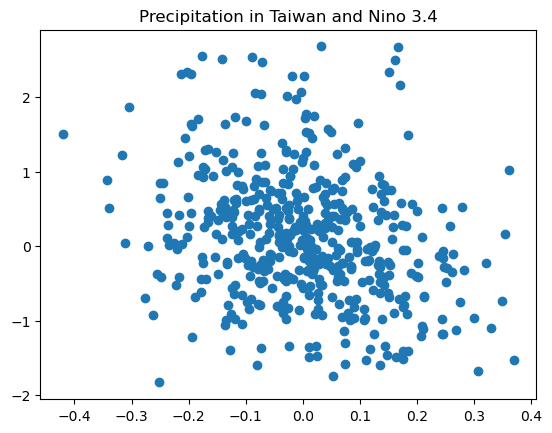

In [15]:
plt.scatter(prec_mean_tai,nino34)
plt.title("Precipitation in Taiwan and Nino 3.4")

In [16]:
#scipy
from scipy.stats import linregress

In [17]:
slope, intercept, r_value, p_value, std_err = linregress(prec_mean_tai,nino34)

In [18]:
slope,intercept,r_value,p_value, std_err

(-1.719773534329039,
 0.13907589185022093,
 -0.26686089141889374,
 1.8144771155892787e-09,
 0.2805730460914176)

Text(0.5, 1.0, 'Regression between Precipitation in Taiwan and Nino3.4 ')

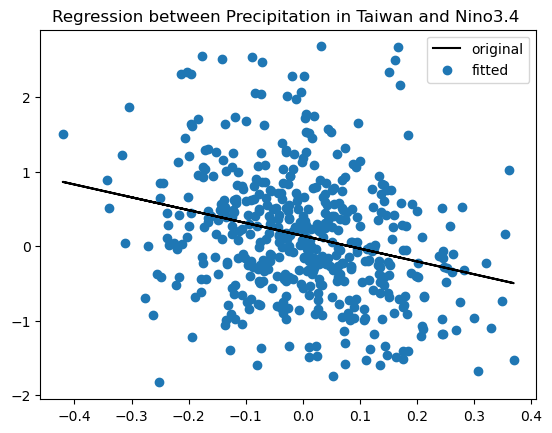

In [20]:
plt.scatter(prec_mean_tai,nino34)
plt.plot(prec_mean_tai, intercept + slope*prec_mean_tai, 'k')
plt.legend(['original','fitted'])
plt.title ("Regression between Precipitation in Taiwan and Nino3.4 ")

In [85]:
r_sq = r_value**2
r_sq

0.07121473536888659

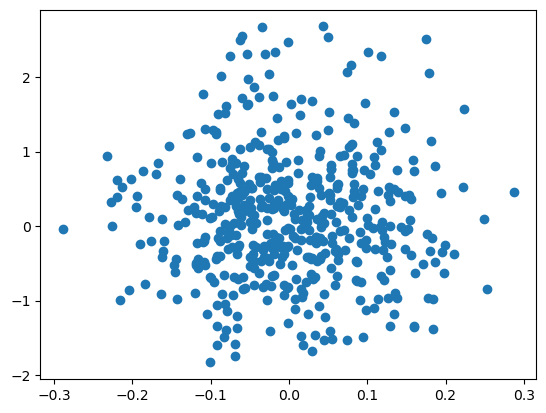

In [86]:
plt.scatter(prec_mean_Mel,nino34)

In [21]:
slope, intercept, r_value, p_value, std_err = linregress(prec_mean_Mel,nino34)

In [22]:
slope,intercept,r_value,p_value, std_err

(-0.08896876661424645,
 0.1390758903559025,
 -0.009898354106576836,
 0.8266477015420723,
 0.4060273297881298)

In [23]:
r_sq = r_value**2
r_sq

9.79774140191865e-05

Text(0.5, 1.0, 'Regression between precipitation in Melbourne and Nino3.4 ')

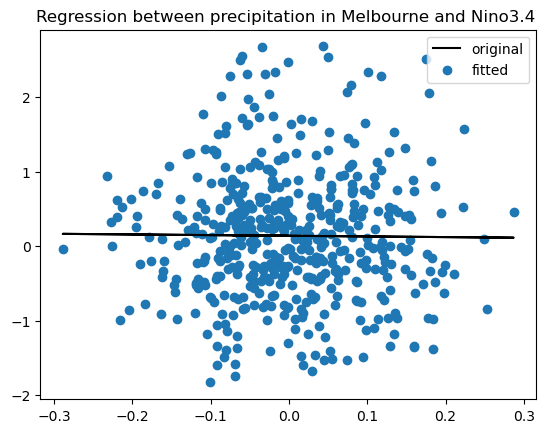

In [89]:
plt.scatter(prec_mean_Mel,nino34)
plt.plot(prec_mean_Mel, intercept + slope*prec_mean_Mel, 'k')
plt.legend(['original','fitted'])
plt.title ("Regression between precipitation in Melbourne and Nino3.4 ")

detrend precipitation data

In [24]:
slope, intercept, r_value, p_value, std_err = linregress(prec_mean_tai_de,nino34)

In [25]:
slope,intercept,r_value,p_value, std_err

(-1.715874874834812,
 0.13907588685746153,
 -0.2646854198348177,
 2.4803674654846074e-09,
 0.28241346590265765)

In [27]:
r_sq = r_value**2
r_sq

0.07005837147313371

Text(0.5, 1.0, 'Regression between Detrended Precipitation in Taiwan and Nino3.4 ')

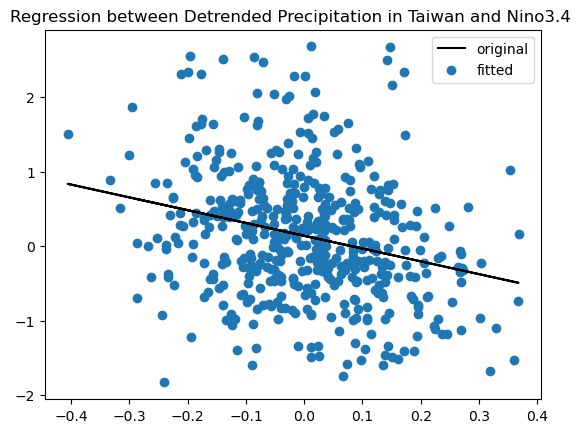

In [26]:
plt.scatter(prec_mean_tai_de,nino34)
plt.plot(prec_mean_tai_de, intercept + slope*prec_mean_tai_de, 'k')
plt.legend(['original','fitted'])
plt.title ("Regression between Detrended Precipitation in Taiwan and Nino3.4 ")

In [28]:
slope, intercept, r_value, p_value, std_err = linregress(prec_mean_mel_de,nino34)

In [29]:
slope,intercept,r_value,p_value, std_err

(-0.1299791453485399,
 0.1390758900259821,
 -0.014346168820626703,
 0.7509246768824434,
 0.4092559513893773)

In [30]:
r_sq = r_value**2
r_sq

0.00020581255982992177

Text(0.5, 1.0, 'Regression between Detrended Precipitation in Melbourne and Nino3.4 ')

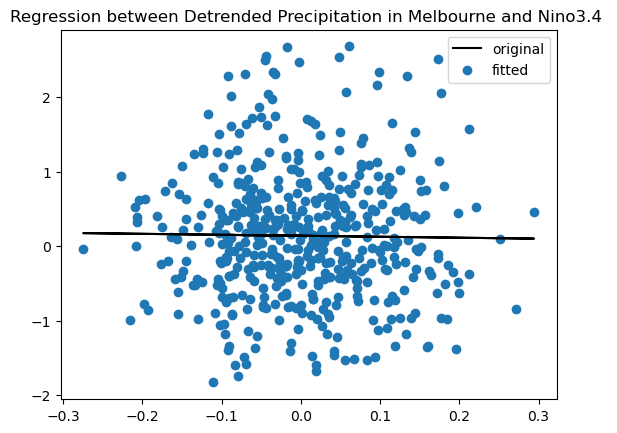

In [31]:
plt.scatter(prec_mean_mel_de,nino34)
plt.plot(prec_mean_mel_de, intercept + slope*prec_mean_mel_de, 'k')
plt.legend(['original','fitted'])
plt.title ("Regression between Detrended Precipitation in Melbourne and Nino3.4 ")

# Temperature

In [32]:
# make precipitation anomaly

temp_clim = temp.air.groupby('time.month').mean(dim = 'time')
temp_anom = temp.air.groupby('time.month') - temp_clim

In [33]:
# make precipitation detrend
from scipy.signal import detrend
temp_anom_detrended = xr.apply_ufunc(detrend, temp_anom.fillna(0),
                                    kwargs={'axis': 0}).where(~temp_anom.isnull())

In [34]:
# raw data: select domain of Taiwan
temp_anom_tai = temp_anom.sel(lat=slice(23.5), lon=slice(120))
temp_mean_tai = temp_anom_tai.mean(dim=('lon', 'lat'))
temp_mean_tai

<xarray.DataArray 'air' (time: 492)>
array([-3.50834918e+00, -3.98114204e+00, -1.85022569e+00, -2.62352777e+00,
       -1.30552840e+00, -3.96769494e-01, -4.10712034e-01, -4.88993526e-01,
       -3.22001606e-01, -1.14258409e+00, -8.28539848e-01,  3.19766328e-02,
       -1.59290373e+00, -8.80987167e-01, -1.21245635e+00, -3.24616343e-01,
       -6.52771115e-01, -3.22520792e-01, -5.48840582e-01, -8.57453883e-01,
       -8.56186867e-01, -1.03453922e+00, -1.46095753e+00, -8.66887093e-01,
       -4.11688030e-01, -1.88559845e-01, -8.82287323e-01, -4.06492859e-01,
       -8.62941623e-01, -1.00607574e-01, -4.34406579e-01, -2.42064605e-04,
       -8.27505529e-01, -5.90705097e-01, -2.45558873e-01, -6.59485579e-01,
       -1.97342157e+00, -1.37776971e+00, -1.53712714e+00, -3.04706782e-01,
       -8.55409324e-01, -9.53351438e-01, -5.19206941e-01, -6.26104057e-01,
       -8.44018757e-01, -1.32331300e+00, -4.12042677e-01,  4.38152790e-01,
        6.21545196e-01, -8.50279868e-01,  7.62214661e-01, -1.29354227e+00,
       -4.70156431e-01, -7.47777760e-01, -1.99922770e-01, -2.67884493e-01,
       -7.78946102e-01, -7.62471080e-01, -3.03936303e-01, -5.97832739e-01,
        1.39938283e+00,  2.31824443e-01, -1.10288060e+00, -2.03397346e+00,
       -1.91705346e-01, -4.81083840e-01, -1.95032507e-01, -6.11267328e-01,
       -3.89608204e-01, -2.24131942e-01, -7.16050446e-01, -1.02379954e+00,
       -1.17433202e+00, -1.60597491e+00, -1.77735901e+00, -7.83052444e-01,
       -1.04837298e+00, -1.83744535e-01, -7.29398608e-01, -1.96934655e-01,
...
        7.74865806e-01,  4.82881367e-01,  1.84870851e+00,  1.45004165e+00,
        4.98953581e-01,  8.37897182e-01,  2.73555422e+00,  1.04065287e+00,
        3.31213117e-01,  5.42079657e-02,  1.56444564e-01,  3.56978625e-01,
        4.01738346e-01,  5.45709550e-01, -3.55617791e-01,  1.28880179e+00,
        6.60111189e-01,  1.80554926e+00,  1.97701097e+00,  1.91753507e+00,
        2.69542545e-01,  8.02879393e-01,  2.53645033e-01,  4.71779048e-01,
        9.07394767e-01,  1.43234587e+00,  2.16735625e+00,  2.42379427e+00,
        2.51902294e+00,  4.31613541e+00,  2.98911095e+00,  1.91866386e+00,
        9.02382135e-01,  8.97340417e-01,  9.10729051e-01,  6.33076966e-01,
        2.15627408e+00,  1.27949858e+00,  2.07629037e+00,  1.83273709e+00,
        2.00468564e+00,  2.26919127e+00,  2.61608887e+00,  7.71120489e-01,
       -3.63727629e-01,  3.47122341e-01,  4.97347534e-01,  4.99387145e-01,
        8.91773522e-01,  1.22688794e+00,  1.61741304e+00,  2.08364034e+00,
        1.60427368e+00,  2.65659070e+00, -1.30665982e-02,  8.34954858e-01,
        1.03519464e+00,  1.01262856e+00,  7.50134230e-01,  9.83504891e-01,
        1.34945107e+00,  2.32863832e+00,  3.99992198e-01,  7.92470694e-01,
        2.52420157e-01,  4.18529928e-01,  1.68060684e+00,  1.39066267e+00,
        7.38215268e-01,  1.11475837e+00,  6.21885359e-01,  8.72581303e-01,
        1.11964345e+00,  1.43497229e+00,  4.72375005e-01,  1.65734279e+00],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

In [35]:
# raw data: select domain of Melbourne
temp_anom_Mel = temp_anom.sel(lat=slice(-35), lon=slice(147))
temp_mean_Mel = temp_anom_Mel.mean(dim=('lon', 'lat'))
temp_mean_Mel

<xarray.DataArray 'air' (time: 492)>
array([-1.7623565 , -1.9804665 , -0.99569356, -1.4085869 , -0.7742699 ,
       -0.24500686, -0.34295455, -0.3092153 , -0.28545427, -0.67523587,
       -0.5072198 ,  0.05267433, -0.64037573, -0.47604898, -0.64764684,
       -0.33864838, -0.31301868, -0.20740095, -0.2981065 , -0.40450987,
       -0.5032298 , -0.61479783, -0.704754  , -0.31122088, -0.20680878,
       -0.20187233, -0.47520202, -0.11047895, -0.51829994, -0.23681903,
       -0.3360889 , -0.15724513, -0.5539788 , -0.4079911 , -0.42339277,
       -0.4266987 , -1.138329  , -0.7558933 , -1.0211526 , -0.42761666,
       -0.648906  , -0.6330732 , -0.42342085, -0.35814565, -0.48338303,
       -0.8178416 , -0.42517787,  0.12344352,  0.13971372, -0.43420413,
        0.40867352, -0.7337879 , -0.19839613, -0.3630441 , -0.14578086,
       -0.03383533, -0.2848515 , -0.6004738 , -0.22399016, -0.37999082,
        0.49823397, -0.11579475, -0.77557236, -1.1154267 , -0.21564153,
       -0.3785743 , -0.25159815, -0.43193665, -0.41322014, -0.2987631 ,
       -0.4581134 , -0.6779302 , -0.5678642 , -0.6945839 , -0.9585179 ,
       -0.5973783 , -0.6532337 , -0.24274193, -0.48869595, -0.1801985 ,
       -0.46488327, -0.68341744, -0.29863343, -0.37022737, -0.771313  ,
       -1.1347967 , -0.6108201 , -0.8165015 , -0.4268606 , -0.22489569,
       -0.25438204, -0.3656438 , -0.85809654, -0.3675101 , -0.18165947,
       -0.8686679 , -0.73191196, -0.60225874, -1.3392603 , -0.37202966,
...
        0.7618658 ,  0.44901776,  0.20494236,  0.09689732,  0.74343514,
        0.46006748,  0.4747586 ,  0.38492945,  0.25097686,  0.7861979 ,
        0.68498737,  1.025561  , -0.42259857,  0.3374312 , -0.10690153,
       -0.09361906,  0.6348159 ,  0.5777776 ,  0.20493959,  0.26662612,
        0.34948328,  0.49661383,  0.30132502,  1.0377171 ,  0.8600615 ,
        0.14746755,  0.33018968,  1.5282196 ,  0.7570441 ,  0.34580484,
        0.20171618,  0.16584088,  0.3054716 ,  0.3363106 ,  0.5250059 ,
        0.0579882 ,  0.6498963 ,  0.3245142 ,  1.1338956 ,  1.1327634 ,
        0.8318871 ,  0.16513976,  0.47856018,  0.25466532,  0.41828978,
        0.6287677 ,  1.117882  ,  1.3313017 ,  1.3177756 ,  1.5376345 ,
        2.1851013 ,  1.8734908 ,  1.2867861 ,  0.6516827 ,  0.51573277,
        0.45652434,  0.32721975,  1.0664036 ,  0.66762316,  1.1771072 ,
        1.06675   ,  1.1652038 ,  1.1294436 ,  1.5619247 ,  0.52339154,
       -0.05445959,  0.3380629 ,  0.46867293,  0.43482667,  0.63580996,
        0.6708284 ,  0.7729969 ,  0.9332778 ,  0.6665554 ,  1.3998421 ,
        0.07198255,  0.63096064,  0.64641637,  0.48958945,  0.37186617,
        0.4922703 ,  0.7278501 ,  1.4704193 ,  0.42470393,  0.6073954 ,
        0.40428507,  0.46104708,  1.149083  ,  1.0405277 ,  0.6169616 ,
        0.70405555,  0.42778602,  0.50344986,  0.75994706,  1.0501188 ,
        0.5612129 ,  1.0757343 ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

In [36]:
# detrend data: select domain of Taiwan
temp_anom_tai_de = temp_anom_detrended.sel(lat=slice(23.5), lon=slice(120))
temp_mean_tai_de = temp_anom_tai_de.mean(dim=('lon', 'lat'))
temp_mean_tai_de

<xarray.DataArray 'air' (time: 492)>
array([-2.32210898e+00, -2.79973364e+00, -6.73649192e-01, -1.45178306e+00,
       -1.38615787e-01,  7.65311301e-01,  7.46536613e-01,  6.63423419e-01,
        8.25583398e-01,  1.68780898e-04,  3.09381217e-01,  1.16506577e+00,
       -4.64646608e-01,  2.42438078e-01, -9.38631222e-02,  7.89144993e-01,
        4.56158251e-01,  7.81576693e-01,  5.50424993e-01,  2.36979738e-01,
        2.33414814e-01,  5.02304100e-02, -3.81019652e-01,  2.08218828e-01,
        6.58586025e-01,  8.76882195e-01,  1.78322956e-01,  6.49285376e-01,
        1.88004568e-01,  9.45506752e-01,  6.06875718e-01,  1.03620839e+00,
        2.04113007e-01,  4.36081439e-01,  7.76395679e-01,  3.57637197e-01,
       -9.61130917e-01, -3.70311052e-01, -5.34500182e-01,  6.93088174e-01,
        1.37553662e-01,  3.47795673e-02,  4.64092195e-01,  3.52363050e-01,
        1.29616439e-01, -3.54509681e-01,  5.51928639e-01,  1.39729214e+00,
        1.57585263e+00,  9.91957188e-02,  1.70685816e+00, -3.53730530e-01,
        4.64823276e-01,  1.82370022e-01,  7.25393116e-01,  6.52599394e-01,
        1.36705860e-01,  1.48348942e-01,  6.02051795e-01,  3.03323507e-01,
        2.29570699e+00,  1.12331688e+00, -2.16220334e-01, -1.15214515e+00,
        6.85291111e-01,  3.91080678e-01,  6.72300100e-01,  2.51233310e-01,
        4.68060523e-01,  6.28704906e-01,  1.31954506e-01, -1.80626690e-01,
       -3.35991025e-01, -7.72465944e-01, -9.48682010e-01,  4.07926813e-02,
       -2.29359731e-01,  6.30436778e-01,  7.99507722e-02,  6.07582808e-01,
...
       -4.89794575e-02, -3.45795810e-01,  1.01519930e+00,  6.11700714e-01,
       -3.44219357e-01, -1.01077082e-02,  1.88271749e+00,  1.82984188e-01,
       -5.31287551e-01, -8.13124657e-01, -7.15719998e-01, -5.20017862e-01,
       -4.80090022e-01, -3.40950817e-01, -1.24711013e+00,  3.92477602e-01,
       -2.41044953e-01,  8.99561346e-01,  1.06619096e+00,  1.00188315e+00,
       -6.50941253e-01, -1.22436352e-01, -6.76502705e-01, -4.63200599e-01,
       -3.24168056e-02,  4.87702310e-01,  1.21788096e+00,  1.46948671e+00,
        1.55988348e+00,  3.35216379e+00,  2.02030754e+00,  9.45028663e-01,
       -7.60850608e-02, -8.59585628e-02, -7.74019659e-02, -3.59886050e-01,
        1.15847909e+00,  2.76871711e-01,  1.06883156e+00,  8.20446312e-01,
        9.87563014e-01,  1.24723673e+00,  1.58930254e+00, -2.60497928e-01,
       -1.40017807e+00, -6.94159985e-01, -5.48766673e-01, -5.51558971e-01,
       -1.64004549e-01,  1.66277900e-01,  5.51971197e-01,  1.01336646e+00,
        5.29167950e-01,  1.57665312e+00, -1.09783638e+00, -2.54646659e-01,
       -5.92388362e-02, -8.66368636e-02, -3.53963107e-01, -1.25424370e-01,
        2.35689729e-01,  1.21004486e+00, -7.23433077e-01, -3.35786521e-01,
       -8.80668938e-01, -7.19391048e-01,  5.37853956e-01,  2.43077561e-01,
       -4.14201558e-01, -4.24904339e-02, -5.40195346e-01, -2.94331312e-01,
       -5.21012321e-02,  2.58395731e-01, -7.09033489e-01,  4.71102566e-01],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

In [37]:
# detrend data: select domain of Taiwan
temp_anom_mel_de = temp_anom_detrended.sel(lat=slice(-35), lon=slice(147))
temp_mean_mel_de = temp_anom_mel_de.mean(dim=('lon', 'lat'))
temp_mean_mel_de

<xarray.DataArray 'air' (time: 492)>
array([-1.03107405e+00, -1.25216281e+00, -2.70368695e-01, -6.86240673e-01,
       -5.49024008e-02,  4.71381783e-01,  3.70455444e-01,  4.01215911e-01,
        4.21998173e-01,  2.92379186e-02,  1.94275171e-01,  7.51190543e-01,
        5.51616922e-02,  2.16509715e-01,  4.19330783e-02,  3.47952873e-01,
        3.70603770e-01,  4.73242819e-01,  3.79558474e-01,  2.70176381e-01,
        1.68477684e-01,  5.39308675e-02, -3.90040092e-02,  3.51550370e-01,
        4.52983737e-01,  4.54941422e-01,  1.78632930e-01,  5.40377319e-01,
        1.29577592e-01,  4.08079714e-01,  3.05831105e-01,  4.81696099e-01,
        8.19836780e-02,  2.24992618e-01,  2.06612259e-01,  2.00327605e-01,
       -5.14281631e-01, -1.34824485e-01, -4.03062582e-01,  1.87494650e-01,
       -3.67734991e-02, -2.39194315e-02,  1.82754189e-01,  2.45050639e-01,
        1.16834506e-01, -2.20602795e-01,  1.69082165e-01,  7.14724779e-01,
        7.28016317e-01,  1.51119724e-01,  9.91018534e-01, -1.54421598e-01,
        3.77991438e-01,  2.10364714e-01,  4.24649239e-01,  5.33616006e-01,
        2.79621094e-01, -3.89800593e-02,  3.34524900e-01,  1.75545543e-01,
        1.05079162e+00,  4.33784068e-01, -2.28972197e-01, -5.71805358e-01,
        3.25001121e-01,  1.59089550e-01,  2.83086956e-01,  9.97696742e-02,
        1.15507491e-01,  2.26985753e-01,  6.46567643e-02, -1.58138826e-01,
       -5.10514565e-02, -1.80750087e-01, -4.47662741e-01, -8.95019174e-02,
       -1.48336068e-01,  2.59176970e-01,  1.02442158e-02,  3.15762907e-01,
...
       -1.12625556e-02, -2.09530115e-01,  5.23883164e-01,  3.43248814e-01,
       -3.72323781e-01, -1.92580462e-01,  1.00247097e+00,  2.28316411e-01,
       -1.85901538e-01, -3.32968920e-01, -3.71823013e-01, -2.35170975e-01,
       -2.07310706e-01, -2.15942133e-02, -4.91590619e-01,  9.73387808e-02,
       -2.31022105e-01,  5.75380445e-01,  5.71269691e-01,  2.67414689e-01,
       -4.02311534e-01, -9.18698609e-02, -3.18743467e-01, -1.58097744e-01,
        4.94014993e-02,  5.35537124e-01,  7.45977879e-01,  7.29473174e-01,
        9.46353495e-01,  1.59084105e+00,  1.27625227e+00,  6.86568558e-01,
        4.84863669e-02, -9.04422775e-02, -1.52629435e-01, -2.84912765e-01,
        4.51292366e-01,  4.95330058e-02,  5.56038439e-01,  4.42702562e-01,
        5.38177609e-01,  4.99438584e-01,  9.28940892e-01, -1.12570979e-01,
       -6.93400741e-01, -3.03857058e-01, -1.76225752e-01, -2.13050768e-01,
       -1.50462408e-02,  1.69934612e-02,  1.16183177e-01,  2.73485363e-01,
        3.78425070e-03,  7.34092295e-01, -5.96746206e-01, -4.07467782e-02,
       -2.82698143e-02, -1.88075468e-01, -3.08777511e-01, -1.91352114e-01,
        4.12488729e-02,  7.80839384e-01, -2.67854750e-01, -8.81420895e-02,
       -2.94231057e-01, -2.40447849e-01,  4.44609284e-01,  3.33075225e-01,
       -9.34695080e-02, -9.35438275e-03, -2.88602650e-01, -2.15917572e-01,
        3.76008749e-02,  3.24793875e-01, -1.67090714e-01,  3.44451874e-01],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

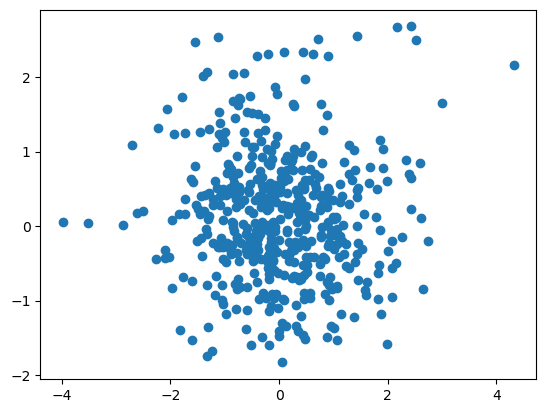

In [38]:
plt.scatter(temp_mean_tai,nino34)

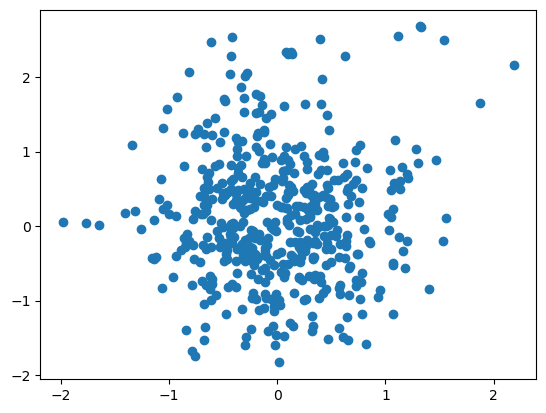

In [39]:
plt.scatter(temp_mean_Mel,nino34)

calculate Taiwan temperature regression

In [40]:
slope, intercept, r_value, p_value, std_err = linregress(temp_mean_tai,nino34)

In [41]:
slope,intercept,r_value,p_value, std_err

(-0.017834402314901774,
 0.13907588963033624,
 -0.02210695218390941,
 0.6247224628271263,
 0.036435564117518804)

In [42]:
r_sq = r_value**2
r_sq

0.0004887173348616571

Text(0.5, 1.0, 'Regression between Precipitation in Taiwan and Nino3.4 ')

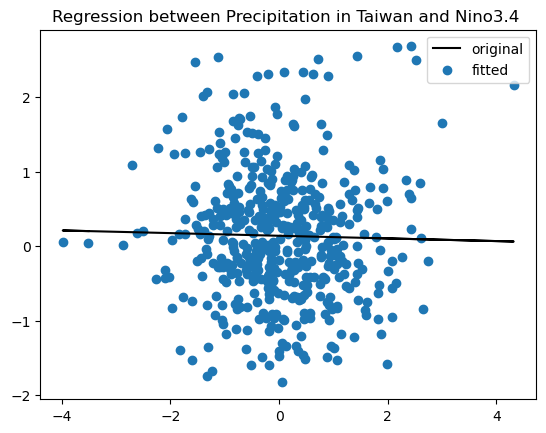

In [43]:
plt.scatter(temp_mean_tai,nino34)
plt.plot(temp_mean_tai, intercept + slope*temp_mean_tai, 'k')
plt.legend(['original','fitted'])
plt.title ("Regression between Precipitation in Taiwan and Nino3.4 ")

calculate Melbourn temperature regression

In [44]:
slope, intercept, r_value, p_value, std_err = linregress(temp_mean_Mel,nino34)

In [45]:
slope,intercept,r_value,p_value, std_err

(0.03269922689105228,
 0.1390758906905124,
 0.02267115356218889,
 0.6159096053252683,
 0.06514096498263747)

In [46]:
r_sq = r_value**2
r_sq

0.0005139812038403499

Text(0.5, 1.0, 'Regression between Precipitation in Melbourne and Nino3.4 ')

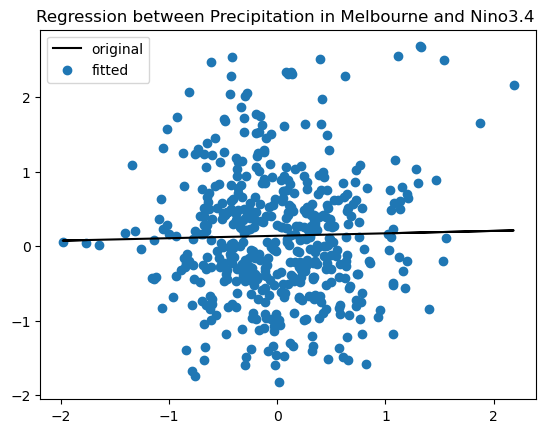

In [47]:
plt.scatter(temp_mean_Mel,nino34)
plt.plot(temp_mean_Mel, intercept + slope*temp_mean_Mel, 'k')
plt.legend(['original','fitted'])
plt.title ("Regression between Precipitation in Melbourne and Nino3.4 ")

calculate Taiwan temperature regression (detrend)

In [48]:
slope, intercept, r_value, p_value, std_err = linregress(temp_mean_tai_de,nino34)

In [49]:
slope,intercept,r_value,p_value, std_err

(0.00038532455650837463,
 0.13907589018643637,
 0.0003631190624817868,
 0.9935899574286704,
 0.04793796236653243)

In [50]:
r_sq = r_value**2
r_sq

1.318554535376518e-07

Text(0.5, 1.0, 'Regression between Detrended Precipitation in Taiwan and Nino3.4 ')

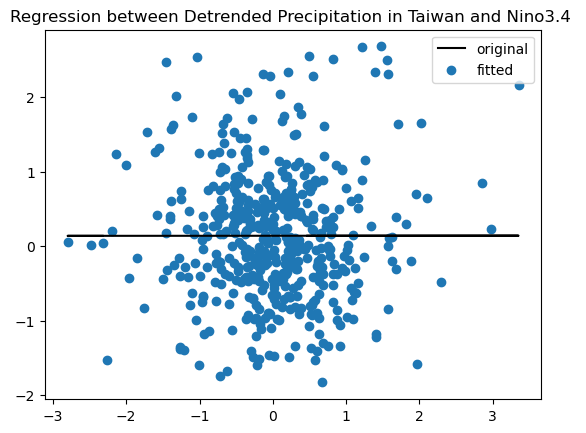

In [112]:
plt.scatter(temp_mean_tai_de,nino34)
plt.plot(temp_mean_tai_de, intercept + slope*temp_mean_tai_de, 'k')
plt.legend(['original','fitted'])
plt.title ("Regression between Detrended Precipitation in Taiwan and Nino3.4 ")

calculate Melbourn temperature regression (detrend)

In [51]:
slope, intercept, r_value, p_value, std_err = linregress(temp_mean_mel_de,nino34)

In [52]:
slope,intercept,r_value,p_value, std_err

(0.14011279398124732,
 0.1390758900476541,
 0.067814938573211,
 0.1330682946986415,
 0.093122246896434)

In [53]:
r_sq = r_value**2
r_sq

0.004598865893688381

Text(0.5, 1.0, 'Regression between Detrended Precipitation in Melbourne and Nino3.4 ')

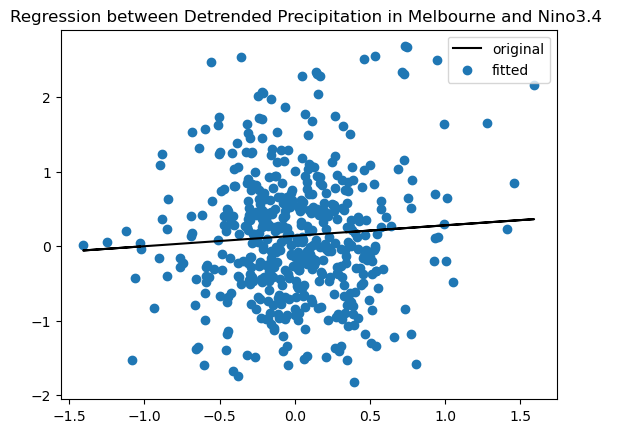

In [54]:
plt.scatter(temp_mean_mel_de,nino34)
plt.plot(temp_mean_mel_de, intercept + slope*temp_mean_mel_de, 'k')
plt.legend(['original','fitted'])
plt.title ("Regression between Detrended Precipitation in Melbourne and Nino3.4 ")

In [ ]:
#select month 
ds = ds.sel(time = ds.time.dt.month.isin([1, 2, 3, 4, 11, 12])) #winter half year
ds